In [1]:
# !unzip data.zip

data zip from [here](https://f000.backblazeb2.com/file/jeldridge-data/016-socal/data.zip)  
  
delete ".zip" file since we aren't given the test set

In [2]:
from pathlib import Path

data_fp = Path("data")

In [3]:
import os
import torch
from PIL import Image
import torchvision.transforms as transforms

_dir = os.getcwd()
_dir

raw_X = list()
raw_y = list()
i = 1
for image_path in os.listdir("data"):
    # print(image_path)
    curr_path = _dir + "/data/" + image_path

    img = Image.open(curr_path)
    tens = transforms.ToTensor()(img)
    raw_X.append(tens)

    label = image_path.split("-")[0]
    raw_y.append(label)

    if i % (len(list(os.listdir("data"))) // 10) == 0:
        print(f"iteration {i}")
    i+=1

print(f"{len(raw_X)} images and labels")
curr_path

iteration 918
iteration 1836
iteration 2754
iteration 3672
iteration 4590
iteration 5508
iteration 6426
iteration 7344
iteration 8262
iteration 9180
9181 images and labels


'/content/data/Riverside-c2bc608d.jpg'

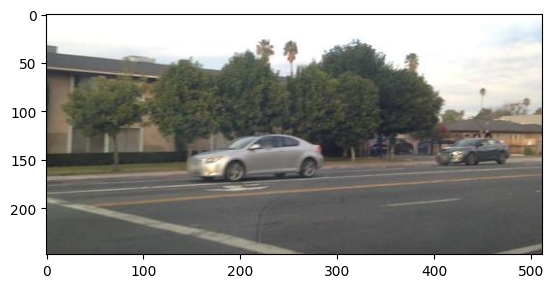

In [4]:
import matplotlib.pyplot as plt

plt.imshow(img)

In [5]:
from sklearn.preprocessing import OneHotEncoder

X = torch.stack(raw_X, dim=0)

raw_y = [[city] for city in raw_y]

ohe = OneHotEncoder()
ohe.fit(raw_y)

y = ohe.transform(raw_y).toarray()
y = torch.tensor(y, dtype=torch.float32)
print(y.shape)
y

torch.Size([9181, 6])


tensor([[0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1.],
        ...,
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.]])

In [6]:
CLASSES = {i: city for i, city in enumerate(ohe.categories_[0])}
CLASSES

{0: 'Anaheim',
 1: 'Bakersfield',
 2: 'Los_Angeles',
 3: 'Riverside',
 4: 'SLO',
 5: 'San_Diego'}

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

X = X.to(device)
y = y.to(device)

device

'cuda'

In [8]:
n_training_samples = 2000
X_train, X_test = X[:n_training_samples], X[n_training_samples:]
y_train, y_test = y[:n_training_samples], y[n_training_samples:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([2000, 3, 248, 512]),
 torch.Size([2000, 6]),
 torch.Size([7181, 3, 248, 512]),
 torch.Size([7181, 6]))

In [10]:
from torch import nn

_, ic, H, W = X.shape

class CNN(nn.Module):
  def __init__(self):
    super().__init__()


n_classes = 6
model = nn.Sequential(
    nn.Conv2d(ic, 32, 7, stride=1),
    nn.BatchNorm2d(32),
    nn.PReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 5),
    nn.BatchNorm2d(64),
    nn.PReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3),
    nn.BatchNorm2d(128),
    nn.PReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(
        218624,
        64
    ),
    nn.Tanh(),

    nn.Linear(
        64,
        512
    ),
    nn.ReLU(),

    nn.Linear(512, n_classes)

).to(device)

# model(X_train).shape

In [11]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset)

batch_size=1024

print(X_train.shape, y_train.shape)
X_train.dtype, y_train.dtype

torch.Size([2000, 3, 248, 512]) torch.Size([2000, 6])


(torch.float32, torch.float32)

Epoch 1
Epoch 6
Epoch 11
Epoch 16
Epoch 21


Text(0, 0.5, 'Loss')

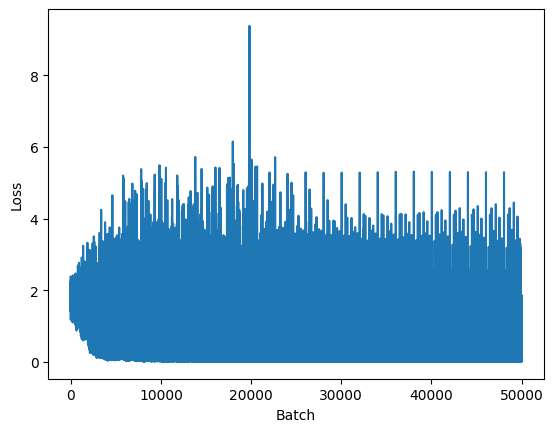

In [12]:
from torch.nn import CrossEntropyLoss
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

loss_fn = CrossEntropyLoss()

loss_li = list()
def train_one_epoch(epoch_index, tb_writer):
    cum_loss = 0
    prev_loss = 0

    for i, (inputs, labels) in enumerate(train_dataloader):
        optim.zero_grad()
        # print(inputs.shape)
        preds = model(inputs)
        # print(preds.shape, labels.shape)
        loss = loss_fn(preds, labels)
        loss.backward()
        optim.step()

        cum_loss += loss.item()
        loss_li.append(loss.item())

        # print(i)
        # break
        # if i+1 % 64 == 0:
        #     prev_loss = cum_loss/1000
        #     # print(f"Batch {i+1} ; Avg. Loss = {prev_loss}")
        #     tb_x = epoch_index * len(train_dataloader) + i + 1
        #     tb_writer.add_scalar("Loss/train", prev_loss, tb_x)
        #     cum_loss = 0

    return prev_loss


lr = 10**-4
optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
# optim = torch.optim.Adam(model.parameters(), lr=lr)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

epochs = 25
best_validation_loss = torch.inf

for epoch in range(epochs):
    if epoch < 10:
      optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
      optim = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.0)


    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)
    if epoch % 5 == 0:
      print(f"Epoch {epoch+1}")

plt.plot(range(len(loss_li)), loss_li)
plt.xlabel("Batch")
plt.ylabel("Loss")

In [13]:
def batch_acc(dataloader):
  model.eval()

  n_correct = 0
  n_samples = 0
  all_preds = list()
  for i, (inputs, labels) in enumerate(dataloader):
    labels = labels.argmax(axis=-1)
    preds = model(inputs).unsqueeze(-1).argmax(axis=1)
    all_preds.append(preds)

    correct = (preds == labels).sum() # .to(dtype=torch.float32).mean(axis=1).sum() # percent correct from each batch. need to average since 6 predictions are made.

    n_samples += len(preds)
    n_correct += correct

  # print(n_correct, n_samples)
  return n_correct/n_samples, all_preds

In [14]:
torch.manual_seed(25)

train_acc, train_preds = batch_acc(train_dataloader)
train_acc, len(train_preds)

(tensor(0.7975, device='cuda:0'), 2000)

In [15]:
torch.manual_seed(25)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset)

test_acc, test_preds = batch_acc(test_dataloader)
test_acc, len(test_preds)

(tensor(0.6375, device='cuda:0'), 7181)

In [16]:
torch.save(model.state_dict(), "model.pt")

In [17]:
torch.save(model.to("cpu").state_dict(), "model.pt")

In [18]:
for param in model.parameters():
  print(param.shape)

torch.Size([32, 3, 7, 7])
torch.Size([32])
torch.Size([32])
torch.Size([32])
torch.Size([1])
torch.Size([64, 32, 5, 5])
torch.Size([64])
torch.Size([64])
torch.Size([64])
torch.Size([1])
torch.Size([128, 64, 3, 3])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([1])
torch.Size([64, 218624])
torch.Size([64])
torch.Size([512, 64])
torch.Size([512])
torch.Size([6, 512])
torch.Size([6])


In [19]:
test_preds[10], y_test[10]

(tensor([[2]], device='cuda:0'),
 tensor([0., 0., 0., 1., 0., 0.], device='cuda:0'))

In [20]:
import pandas as pd
from sklearn.metrics import confusion_matrix

train_diffs = pd.DataFrame({
    "train_preds": torch.cat(train_preds).detach().cpu().flatten(),
    "train_labels": y_train.detach().cpu().argmax(dim=1),
})

confusion_matrix(train_diffs["train_preds"], train_diffs["train_labels"], normalize="true")

array([[0.71506849, 0.13972603, 0.09315068, 0.03013699, 0.00547945,
        0.01643836],
       [0.13522013, 0.75786164, 0.0408805 , 0.02201258, 0.02201258,
        0.02201258],
       [0.12068966, 0.00344828, 0.76551724, 0.03793103, 0.03793103,
        0.03448276],
       [0.02439024, 0.03523035, 0.06233062, 0.78319783, 0.01897019,
        0.07588076],
       [0.00898204, 0.00299401, 0.01497006, 0.00299401, 0.96407186,
        0.00598802],
       [0.05246914, 0.02160494, 0.06481481, 0.04938272, 0.00925926,
        0.80246914]])

In [21]:
test_diffs = pd.DataFrame({
    "test_preds": torch.cat(test_preds).detach().cpu().flatten(),
    "test_labels": y_test.detach().cpu().argmax(dim=1),
})

confusion_matrix(test_diffs["test_preds"], test_diffs["test_labels"], normalize="true")

array([[0.4743295 , 0.21302682, 0.16475096, 0.04137931, 0.03524904,
        0.07126437],
       [0.1930605 , 0.62099644, 0.05427046, 0.06049822, 0.02313167,
        0.0480427 ],
       [0.18409091, 0.05568182, 0.55227273, 0.03977273, 0.07159091,
        0.09659091],
       [0.04779874, 0.04528302, 0.09685535, 0.64025157, 0.0245283 ,
        0.14528302],
       [0.03159693, 0.01964133, 0.05123826, 0.00341588, 0.88385995,
        0.01024765],
       [0.09450945, 0.04860486, 0.12151215, 0.06120612, 0.02430243,
        0.64986499]])

In [22]:
a = pd.Series(y_train.detach().cpu().argmax(dim=1)).value_counts(normalize=True).sort_index()
b = pd.Series(y_test.detach().cpu().argmax(dim=1)).value_counts(normalize=True).sort_index()

a-b

,proportion
0,0.014664
1,-0.006487
2,0.004286
3,-0.006153
4,0.003879
5,-0.010190


# Loading the model for prediction submission

In [29]:
def predict(test_dir):
    """Load the saved model and predict a label for every image in `test_dir`.

    Parameters
    ----------
    test_dir : pathlib.Path
        Path to a directory containing .jpg test images.

    Returns
    -------
    dict[str, str]
        A dictionary mapping each image filename (e.g. "00001.jpg") to a predicted
        class label (e.g. "Los_Angeles").

    """
    from pathlib import Path
    test_dir = Path(test_dir)


    # Step 1) load the trained model.
    n_classes = 6
    loaded_model = nn.Sequential(
        nn.Conv2d(ic, 32, 7, stride=1),
        nn.BatchNorm2d(32),
        nn.PReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32, 64, 5),
        nn.BatchNorm2d(64),
        nn.PReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, 3),
        nn.BatchNorm2d(128),
        nn.PReLU(),
        nn.MaxPool2d(2),

        nn.Flatten(),
        nn.Linear(
            218624,
            64
        ),
        nn.Tanh(),

        nn.Linear(
            64,
            512
        ),
        nn.ReLU(),

        nn.Linear(512, n_classes)

    )

    loaded_model.load_state_dict(torch.load("model.pt", weights_only=True))

    # Step 2) run prediction on every test image.
    CLASSES = {
      0: 'Anaheim',
      1: 'Bakersfield',
      2: 'Los_Angeles',
      3: 'Riverside',
      4: 'SLO',
      5: 'San_Diego'
    }
    predictions = {}
    if not test_dir:
      return print("out")
    with torch.no_grad():
        for path in sorted(test_dir.glob("*.jpg")):
            img = Image.open(curr_path)
            image = tens = transforms.ToTensor()(img)
            output = model(image)
            predicted_index = output.argmax(dim=1).item()
            predictions[path.name] = CLASSES[predicted_index]

    return predictions

predict("")

{}